In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from enum import Enum
import os
import shutil
from sklearn.ensemble import GradientBoostingClassifier
import time
from datetime import datetime
import torch
from typing import List, Dict, Any

In [10]:
from temain import TemainProcess
import importlib
import v2_utils
import generators
import autoencoders
import dataset_utils
importlib.reload(v2_utils)
# importlib.reload(generators)
importlib.reload(autoencoders)
importlib.reload(dataset_utils)
from v2_utils import ExperimentRunner, plot_with_anomalies, AdvancedDetectionEvaluator, BaseAnomalyDetector, ExperimentRunner
from autoencoders import RecurrentAutoencoder
from generators import ParallelDataGenerator, SingleProcessGenerator, N_DV
from dataset_utils import CSVDataLoader
def recreate_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


In [3]:

def run_experiments_by_anomaly(
        anomaly_numbers: List[int],
        data_dir_template: str = "./gen_data/gen_data_{}",
        model_params_list=None,
        file_fraction=0.01,
        anomaly_ratio=0.11,
        max_samples=None,
        result_title="",
        results_path="./results/my",
        window=30,
        autoencoder=None,
    ):
    timestamp = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
    results_path = f"{results_path}/{timestamp}_{result_title if result_title else ""}"
    recreate_dir(results_path)
    # timestamp = "-"
    normal_dir = data_dir_template.format(0)
    all_best_models = []
    all_best_per_detector = []
    
    for i in anomaly_numbers:
        print(f"\n{'='*50}")
        print(f"Запуск экспериментов для аномалии {i}")
        print(f"{'='*50}")
        start_time = time.time()
        
        data_dir = data_dir_template.format(i)
        
        
        data_gen = CSVDataLoader(data_dir, 
                                 file_fraction=file_fraction,
                                 normal_dir=normal_dir, 
                                 max_samples=max_samples,
                                 anomaly_ratio=anomaly_ratio,
                                 shuffle=True,
                                 normalize=True)
        
        runner = ExperimentRunner(data_gen, evaluator=AdvancedDetectionEvaluator)
        
        runner.register_detector(
            'IsolationForest', 
            IsolationForest,
            {'random_state': 42, 'contamination': 0.1}
        )

        runner.register_detector(
            'LocalOutlierFactor', 
            LocalOutlierFactor,
            {'contamination': 0.1, "novelty": True}
        )

        runner.register_detector(
            'OneClassSVM', 
            OneClassSVM,
            {'kernel': 'linear', 'nu': 0.1} # {'kernel': 'rbf', 'gamma': 'auto', 'nu': 0.1}
        )
        # runner.register_detector(
        #     'GradientBoosting', 
        #     GradientBoostingClassifier,
        #     {'random_state': 42}
        # )
        
        results = runner.run_comprehensive_experiments(
            model_params_list=model_params_list,
            test_delays=None,
            autoencoder=autoencoder,
            window=window,
        )
        
        # filename = f"{results_path}/experiments_results_{i}.csv"
        # results.to_csv(filename, index=False)
        # print(f"Результаты сохранены в {filename}")
        
        best_pr = runner.get_best_models('pr_auc', top_k=1)
        best_pr['anomaly_number'] = i
        best_pr['best_by_metric'] = 'pr_auc'
        all_best_models.append(best_pr)
        scores_filename = f"{results_path}/scores_ANOM{i}.npy"
        np.save(scores_filename, np.stack([best_pr["test_scores"], best_pr["test_target"]]))
        print(f"Скоры и метки для test сохранены в {scores_filename}")
        
        best_roc = runner.get_best_models('roc_auc', top_k=1)
        best_roc['anomaly_number'] = i
        best_roc['best_by_metric'] = 'roc_auc'
        all_best_models.append(best_roc)
        # f1 ?
        
        best_per_detector = runner.get_best_per_detector('pr_auc')
        if not best_per_detector.empty:
            best_per_detector['anomaly_number'] = i
            all_best_per_detector.append(best_per_detector)
        if best_pr.iloc[0]["survival_km"]:
            best_pr.iloc[0]["survival_km"].plot_survival_function()
            plt.title('Функции выживаемости времени обнаружения аномалий')
            plt.ylabel('Вероятность необнаружения аномалии')
            plt.xlabel('Время (шаги)')
            # plt.ylim(0, 1)
            plt.grid(True)
            plt.show()
        
        print(f"Аномалия {i}:")
        print(f"  - Лучший PR AUC: {best_pr['pr_auc'].iloc[0]:.4f} ({best_pr['detector'].iloc[0]})")
        print(f"  - Лучший ROC AUC: {best_roc['roc_auc'].iloc[0]:.4f} ({best_roc['detector'].iloc[0]})")
        # print(f"  - Лучший F1: {best_f1['f1_score'].iloc[0]:.4f} ({best_f1['detector'].iloc[0]})")
        cur = time.time()
        print(f"\n-------------------\nВремя выполнения: {cur - start_time:.4f} секунд\n")
    
    if all_best_models and all_best_per_detector:
        summary_df = pd.concat(all_best_models, ignore_index=True)
        numeric_cols = summary_df.select_dtypes(include=['number', 'bool', 'int64', 'float64', 'string']).columns.tolist()
        numeric_cols += [col for col in summary_df.columns if summary_df[col].dtype == 'object' and all(isinstance(x, str) for x in summary_df[col].dropna().head(10))]
        summary_df = summary_df[numeric_cols]
        summary_filename = f"{results_path}/best_models_summary.csv"
        summary_df.to_csv(summary_filename, index=False)
        print(f"\nСводная таблица сохранена в {summary_filename}")
        
        per_detector_df = pd.concat(all_best_per_detector, ignore_index=True)
        pivot_df = per_detector_df.pivot_table(
            index='anomaly_number', 
            columns='detector', 
            values='pr_auc',
            aggfunc='first'
        )
        pivot_filename = f"{results_path}/pr_auc_pivot.csv"
        pivot_df.to_csv(pivot_filename)
        print(f"Сводная таблица PR AUC по детекторам сохранена в {pivot_filename}")
        return summary_df, pivot_df
    return None, None




Запуск экспериментов для аномалии 1
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM1.npy


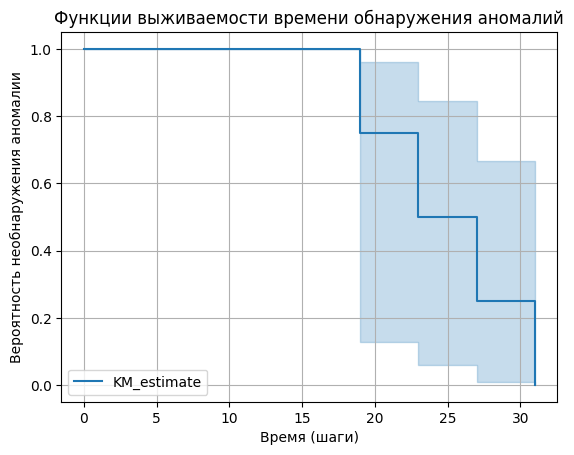

Аномалия 1:
  - Лучший PR AUC: 0.9501 (IsolationForest)
  - Лучший ROC AUC: 0.9752 (IsolationForest)

-------------------
Время выполнения: 344.5512 секунд


Запуск экспериментов для аномалии 2
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM2.npy


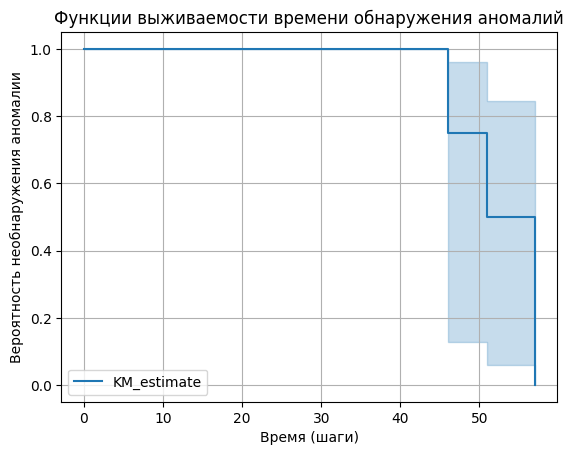

Аномалия 2:
  - Лучший PR AUC: 0.8708 (IsolationForest)
  - Лучший ROC AUC: 0.9329 (IsolationForest)

-------------------
Время выполнения: 343.4557 секунд


Запуск экспериментов для аномалии 3
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM3.npy


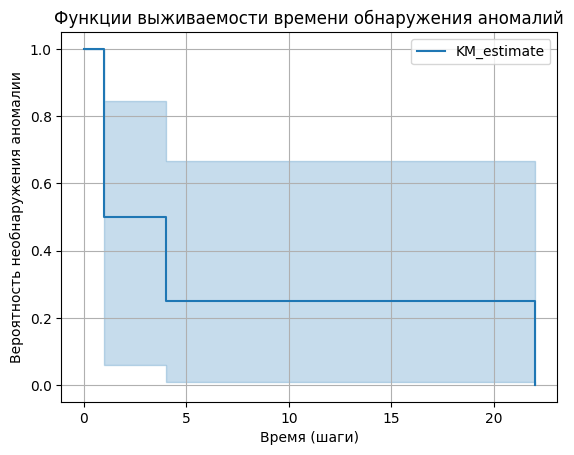

Аномалия 3:
  - Лучший PR AUC: 0.0459 (IsolationForest)
  - Лучший ROC AUC: 0.4817 (LocalOutlierFactor)

-------------------
Время выполнения: 419.6768 секунд


Запуск экспериментов для аномалии 4
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM4.npy


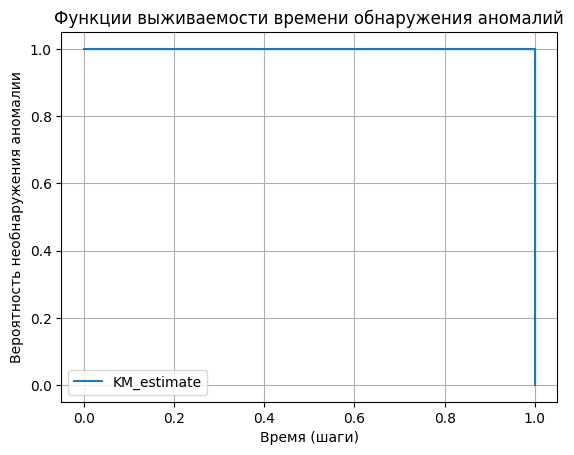

Аномалия 4:
  - Лучший PR AUC: 0.0552 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5382 (LocalOutlierFactor)

-------------------
Время выполнения: 417.8457 секунд


Запуск экспериментов для аномалии 5
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM5.npy


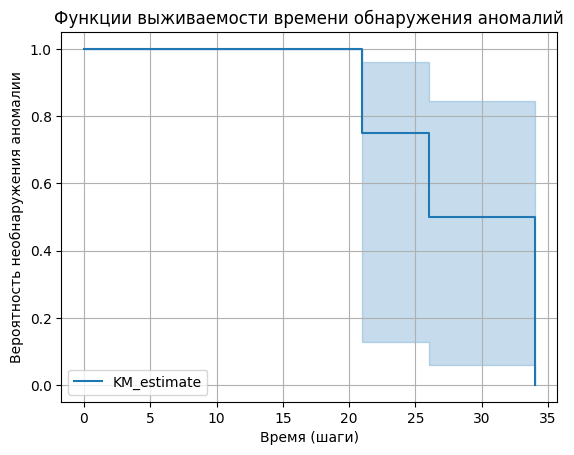

Аномалия 5:
  - Лучший PR AUC: 0.7956 (IsolationForest)
  - Лучший ROC AUC: 0.9363 (IsolationForest)

-------------------
Время выполнения: 366.0220 секунд


Запуск экспериментов для аномалии 6
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM6.npy


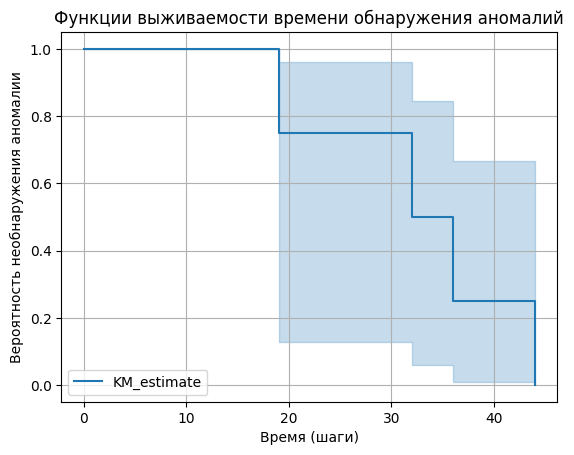

Аномалия 6:
  - Лучший PR AUC: 0.9313 (IsolationForest)
  - Лучший ROC AUC: 0.9705 (IsolationForest)

-------------------
Время выполнения: 342.9878 секунд


Запуск экспериментов для аномалии 7
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM7.npy


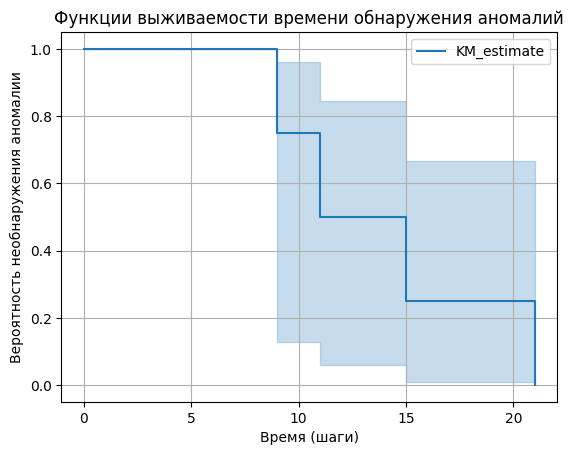

Аномалия 7:
  - Лучший PR AUC: 0.9657 (IsolationForest)
  - Лучший ROC AUC: 0.9888 (IsolationForest)

-------------------
Время выполнения: 360.0041 секунд


Запуск экспериментов для аномалии 8
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM8.npy


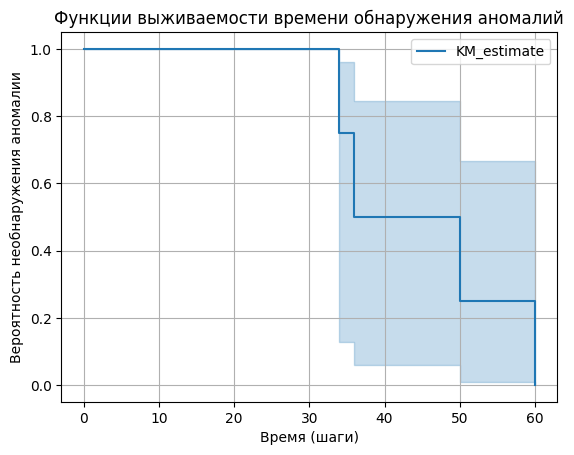

Аномалия 8:
  - Лучший PR AUC: 0.8815 (IsolationForest)
  - Лучший ROC AUC: 0.9479 (IsolationForest)

-------------------
Время выполнения: 392.4822 секунд


Запуск экспериментов для аномалии 9
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM9.npy


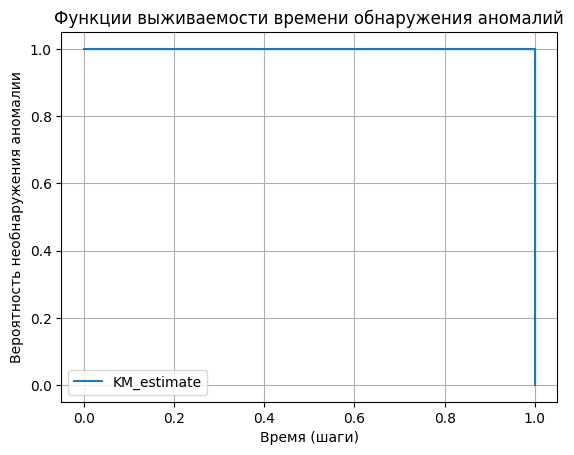

Аномалия 9:
  - Лучший PR AUC: 0.0456 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.4844 (LocalOutlierFactor)

-------------------
Время выполнения: 459.8318 секунд


Запуск экспериментов для аномалии 10
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM10.npy


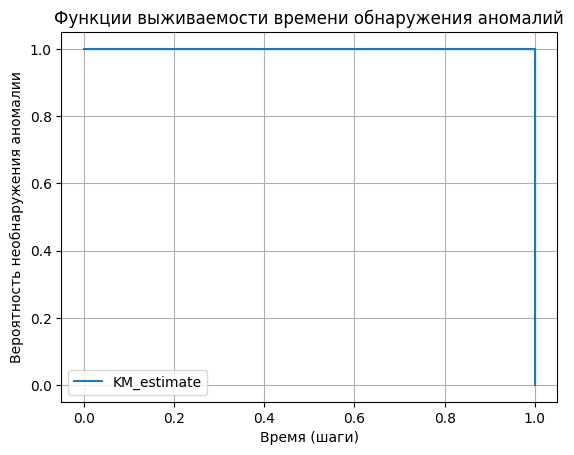

Аномалия 10:
  - Лучший PR AUC: 0.3498 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.7242 (LocalOutlierFactor)

-------------------
Время выполнения: 437.5097 секунд


Запуск экспериментов для аномалии 11
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM11.npy


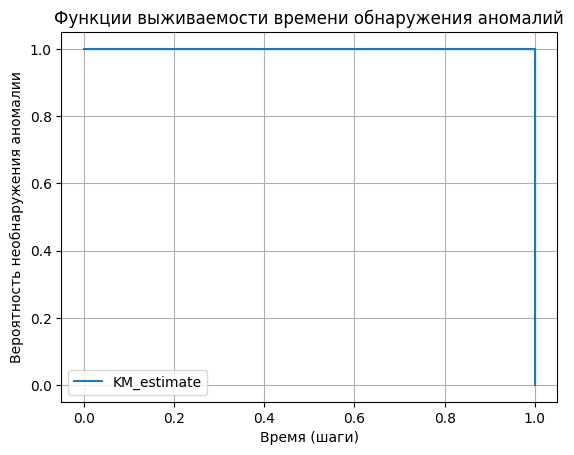

Аномалия 11:
  - Лучший PR AUC: 0.0515 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5223 (LocalOutlierFactor)

-------------------
Время выполнения: 461.6449 секунд


Запуск экспериментов для аномалии 12
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM12.npy


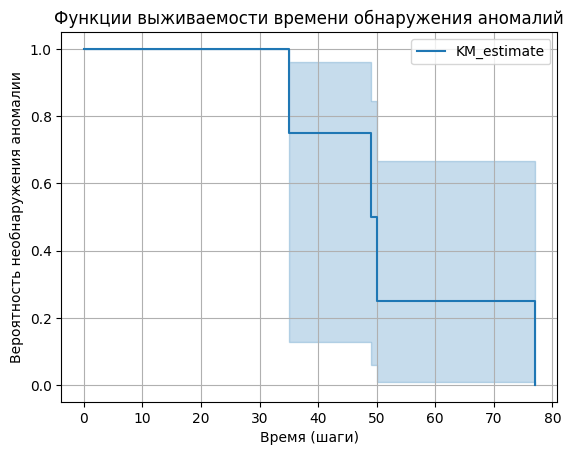

Аномалия 12:
  - Лучший PR AUC: 0.7963 (IsolationForest)
  - Лучший ROC AUC: 0.9182 (IsolationForest)

-------------------
Время выполнения: 391.3694 секунд


Запуск экспериментов для аномалии 13
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM13.npy


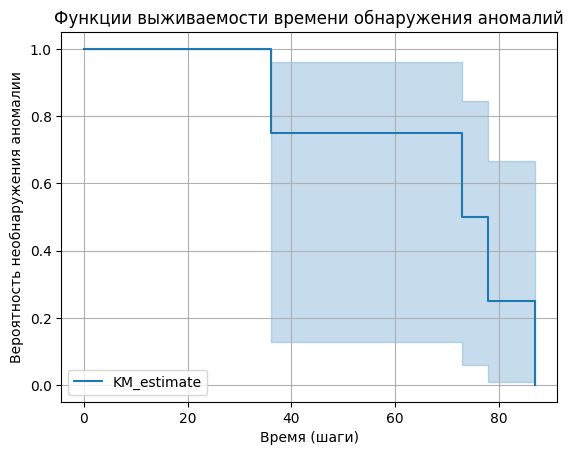

Аномалия 13:
  - Лучший PR AUC: 0.8124 (IsolationForest)
  - Лучший ROC AUC: 0.8872 (IsolationForest)

-------------------
Время выполнения: 381.8416 секунд


Запуск экспериментов для аномалии 14
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM14.npy


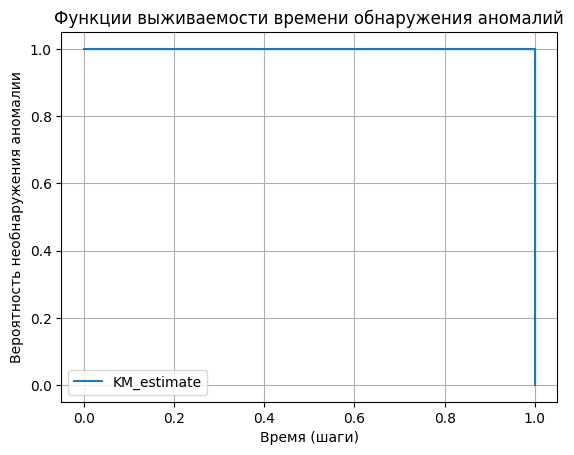

Аномалия 14:
  - Лучший PR AUC: 0.0470 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.4956 (LocalOutlierFactor)

-------------------
Время выполнения: 406.9137 секунд


Запуск экспериментов для аномалии 15
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM15.npy


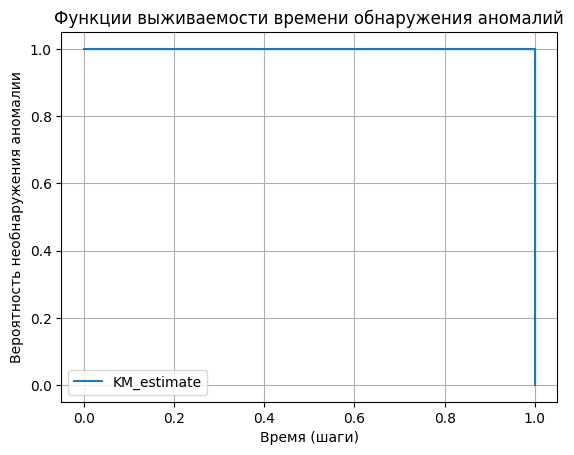

Аномалия 15:
  - Лучший PR AUC: 0.0441 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.4711 (LocalOutlierFactor)

-------------------
Время выполнения: 426.9930 секунд


Запуск экспериментов для аномалии 16
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM16.npy


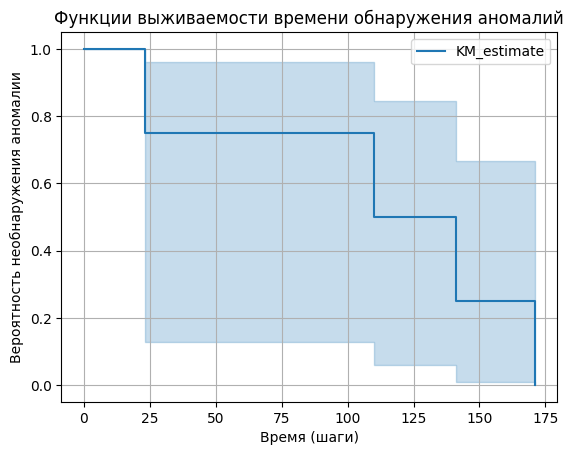

Аномалия 16:
  - Лучший PR AUC: 0.1411 (IsolationForest)
  - Лучший ROC AUC: 0.6193 (LocalOutlierFactor)

-------------------
Время выполнения: 416.7887 секунд


Запуск экспериментов для аномалии 17
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM17.npy


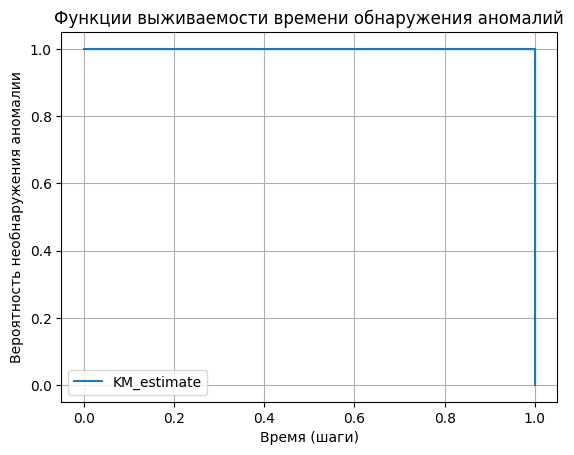

Аномалия 17:
  - Лучший PR AUC: 0.1375 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.7025 (LocalOutlierFactor)

-------------------
Время выполнения: 411.9647 секунд


Запуск экспериментов для аномалии 18
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM18.npy


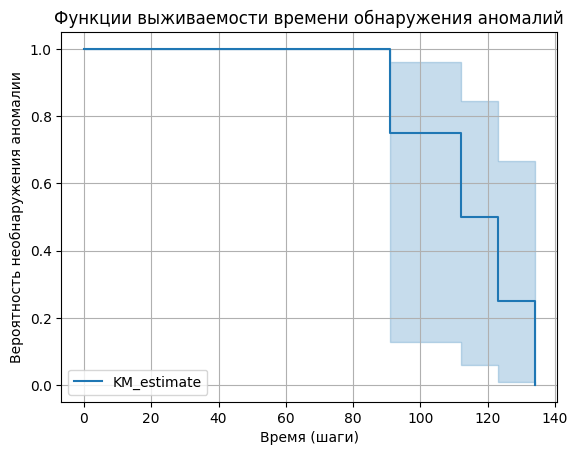

Аномалия 18:
  - Лучший PR AUC: 0.6445 (IsolationForest)
  - Лучший ROC AUC: 0.8060 (IsolationForest)

-------------------
Время выполнения: 366.9774 секунд


Запуск экспериментов для аномалии 19
   Итого: X.shape=(79999, 100, 53), y.shape=(79999,)
   Доля аномалий: 0.0675
Применяем автоэнкодер к данным. Исходная форма: (79999, 100, 53)
После автоэнкодера: (79999, 400)
X_train.shape=(55763, 400), y_train.shape=(55763,), X_test.shape=(24236, 400), y_test.shape=(24236,), y_train.mean()=np.float64(0.07531875975108943), y_test.mean()=np.float64(0.04951312097705892)
Скоры и метки для test сохранены в results/cleared/2026-05-13_19:41:34_w100_rae/scores_ANOM19.npy


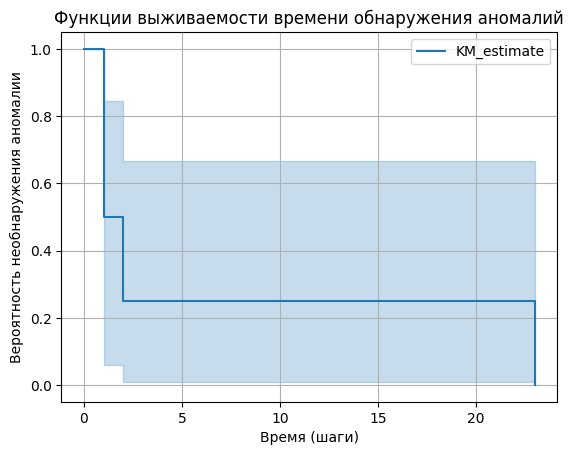

Аномалия 19:
  - Лучший PR AUC: 0.0467 (IsolationForest)
  - Лучший ROC AUC: 0.4838 (LocalOutlierFactor)

-------------------
Время выполнения: 424.5994 секунд


Сводная таблица сохранена в results/cleared/2026-05-13_19:41:34_w100_rae/best_models_summary.csv
Сводная таблица PR AUC по детекторам сохранена в results/cleared/2026-05-13_19:41:34_w100_rae/pr_auc_pivot.csv


In [14]:
model_params_list = {
    'IsolationForest': [
        # {'n_estimators': 200, 'contamination': 0.1, "random_state": 42},
        {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.1, 'random_state': 42},
        # {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.05, 'random_state': 42},
        # {'n_estimators': 50, 'max_samples': 1.0, 'contamination': 0.1, 'random_state': 42},
        # {'n_estimators': 100, 'max_samples': 0.5, 'contamination': 'auto', 'random_state': 42}
    ],
    'LocalOutlierFactor': [
        # {'n_neighbors': 50, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 20, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 10, 'contamination': 0.05, 'novelty': True},
        # {'n_neighbors': 10, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 50, 'contamination': 0.15, 'novelty': True},
        {'n_neighbors': 20, 'contamination': 'auto', 'novelty': True}
    ],
    'OneClassSVM': [
        # {'kernel': 'rbf', 'nu': 0.1},
        # {'kernel': 'rbf', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.15},
        # {'kernel': 'linear', 'nu': 0.2},
        # {'kernel': 'linear', 'nu': 0.10},
        # {'kernel': 'poly', 'nu': 0.15},
    ],
    # 'GradientBoosting': [
    #     {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42},
    #     {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42},
    #     {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'random_state': 42},
    # ]
}

window=100
model_saved_path = f"./models/new_autoencoder_w100_v3.pth"
# model_saved_path = f"./models/new_autoencoder_layer2_w15.pth"

RecurrentAutoencoder.from_pretrained(model_saved_path)
autoencoder.eval()

anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_reduced/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.03,
                                     anomaly_ratio=0.08,
                                     window=window,
                                     result_title="w100_rae",
                                     results_path="results/cleared",
                                     autoencoder=autoencoder,
                                     )

In [15]:
summary

,roc_auc,pr_auc,optimal_thr,eer,precision,recall,f1_score,accuracy,fdr,far,...,size,anomaly_ratio,n_neighbors,nu,anomaly_number,detector,max_samples,freq,kernel,best_by_metric
0,0.975234,0.950112,6.655687e-01,0.051276,0.988299,0.915000,0.950238,0.995255,0.915000,0.000564,...,79999,0.067501,NaN,NaN,1,IsolationForest,auto,3min,NaN,pr_auc
1,0.975234,0.950112,6.655687e-01,0.051276,0.988299,0.915000,0.950238,0.995255,0.915000,0.000564,...,79999,0.067501,NaN,NaN,1,IsolationForest,auto,3min,NaN,roc_auc
2,0.932928,0.870808,6.853601e-01,0.123301,0.981095,0.821667,0.894331,0.990386,0.821667,0.000825,...,79999,0.067501,NaN,NaN,2,IsolationForest,auto,3min,NaN,pr_auc
3,0.932928,0.870808,6.853601e-01,0.123301,0.981095,0.821667,0.894331,0.990386,0.821667,0.000825,...,79999,0.067501,NaN,NaN,2,IsolationForest,auto,3min,NaN,roc_auc
4,0.461188,0.045851,1.364964e-01,0.525983,0.047000,0.635833,0.087530,0.343621,0.635833,0.671601,...,79999,0.067501,NaN,NaN,3,IsolationForest,auto,3min,NaN,pr_auc
5,0.481685,0.045551,1.139320e-08,0.510014,0.049513,1.000000,0.094354,0.049513,1.000000,1.000000,...,79999,0.067501,20.0,NaN,3,LocalOutlierFactor,NaN,3min,NaN,roc_auc
6,0.538159,0.055249,8.607852e-09,0.473188,0.049513,1.000000,0.094354,0.049513,1.000000,1.000000,...,79999,0.067501,20.0,NaN,4,LocalOutlierFactor,NaN,3min,NaN,pr_auc
7,0.538159,0.055249,8.607852e-09,0.473188,0.049513,1.000000,0.094354,0.049513,1.000000,1.000000,...,79999,0.067501,20.0,NaN,4,LocalOutlierFactor,NaN,3min,NaN,roc_auc
8,0.936307,0.795555,6.341895e-01,0.140568,0.840160,0.700833,0.764198,0.978586,0.700833,0.006946,...,79999,0.067501,NaN,NaN,5,IsolationForest,auto,3min,NaN,pr_auc
9,0.936307,0.795555,6.341895e-01,0.140568,0.840160,0.700833,0.764198,0.978586,0.700833,0.006946,...,79999,0.067501,NaN,NaN,5,IsolationForest,auto,3min,NaN,roc_auc


In [16]:
summary_detectors

detector,IsolationForest,LocalOutlierFactor,OneClassSVM
anomaly_number,,,
1,0.950112,0.032089,0.934292
2,0.870808,0.064867,0.847486
3,0.045851,0.045551,0.045142
4,0.046772,0.055249,0.052901
5,0.795555,0.078020,0.384638
6,0.931314,0.397994,0.877752
7,0.965651,0.029571,0.673579
8,0.881528,0.605727,0.738192
9,0.045275,0.045649,0.042890


In [4]:
importlib.reload(autoencoders)
from autoencoders import RecurrentAutoencoder


Запуск экспериментов для аномалии 1
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_14:04:13_rae_w50/scores_ANOM1.npy


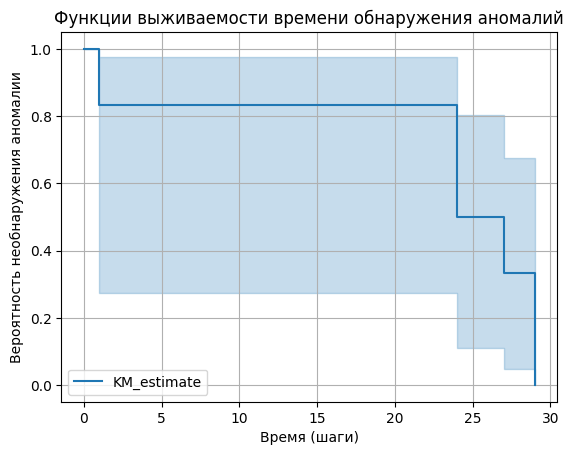

Аномалия 1:
  - Лучший PR AUC: 0.2144 (IsolationForest)
  - Лучший ROC AUC: 0.8444 (IsolationForest)

-------------------
Время выполнения: 686.5359 секунд


Запуск экспериментов для аномалии 2
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)


In [ ]:
model_params_list = {
    'IsolationForest': [
        # {'n_estimators': 200, 'contamination': 0.1, "random_state": 42},
        {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.1, 'random_state': 42},
        {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.05, 'random_state': 42},
        # {'n_estimators': 50, 'max_samples': 1.0, 'contamination': 0.1, 'random_state': 42},
        # {'n_estimators': 100, 'max_samples': 0.5, 'contamination': 'auto', 'random_state': 42}
    ],
    'LocalOutlierFactor': [
        # {'n_neighbors': 50, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 20, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 20, 'contamination': 0.05, 'novelty': True},
        {'n_neighbors': 10, 'contamination': 0.05, 'novelty': True},
        # {'n_neighbors': 10, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 50, 'contamination': 0.15, 'novelty': True},
        {'n_neighbors': 20, 'contamination': 'auto', 'novelty': True}
    ],
    'OneClassSVM': [
        # {'kernel': 'rbf', 'nu': 0.1},
        # {'kernel': 'rbf', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.15},
        # {'kernel': 'linear', 'nu': 0.2},
        # {'kernel': 'linear', 'nu': 0.10},
        # {'kernel': 'poly', 'nu': 0.15},
    ],
    # 'GradientBoosting': [
    #     {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42},
    #     {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42},
    #     {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'random_state': 42},
    # ]
}

anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]
window = 50

model_saved_path = f"./models/new_autoencoder_w100_v3.pth"
autoencoder = RecurrentAutoencoder.from_pretrained(model_saved_path)
autoencoder.eval()

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_large_warmup/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.2,
                                     anomaly_ratio=0.10,
                                     window=window,
                                     result_title=f"rae_w{window}",
                                     results_path="results/cleared",
                                     autoencoder=autoencoder
                                     )

In [11]:
summary_detectors

detector,IsolationForest,LocalOutlierFactor,OneClassSVM
anomaly_number,,,
1,0.214378,0.073250,0.081861
2,0.242067,0.241640,0.076256
3,0.099680,0.075007,0.121605
4,0.136048,0.154914,0.180712
5,0.188050,0.091823,0.148292
6,0.471667,0.219946,0.084013
7,0.168866,0.070763,0.165008
8,0.250543,0.118206,0.135718
9,0.134694,0.080945,0.063158



Запуск экспериментов для аномалии 1
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM1.npy


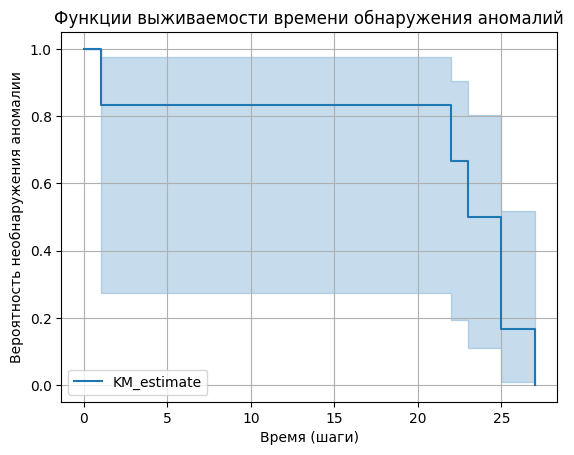

Аномалия 1:
  - Лучший PR AUC: 0.2674 (IsolationForest)
  - Лучший ROC AUC: 0.8493 (IsolationForest)

-------------------
Время выполнения: 625.6189 секунд


Запуск экспериментов для аномалии 2
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM2.npy


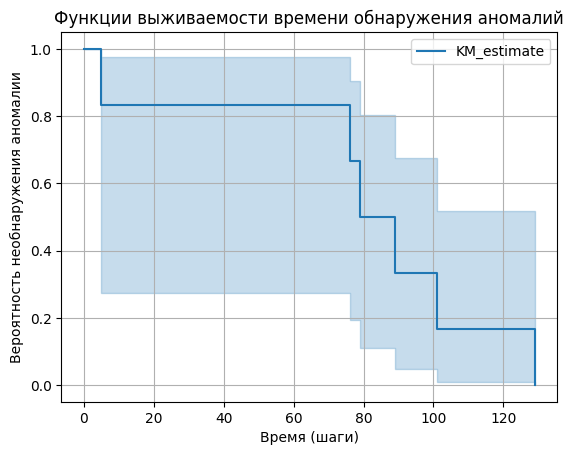

Аномалия 2:
  - Лучший PR AUC: 0.2886 (OneClassSVM)
  - Лучший ROC AUC: 0.8384 (IsolationForest)

-------------------
Время выполнения: 633.4680 секунд


Запуск экспериментов для аномалии 3
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM3.npy


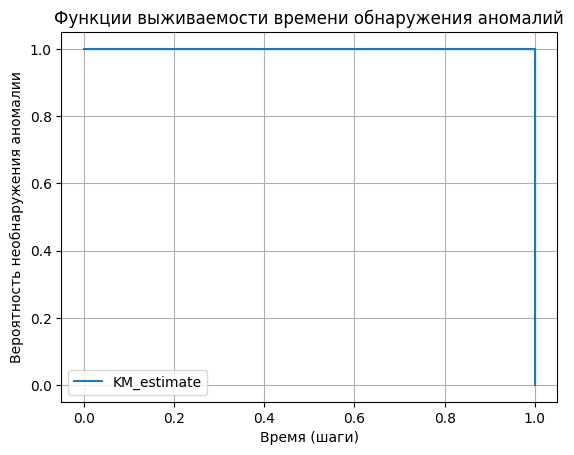

Аномалия 3:
  - Лучший PR AUC: 0.1062 (IsolationForest)
  - Лучший ROC AUC: 0.5839 (LocalOutlierFactor)

-------------------
Время выполнения: 633.1336 секунд


Запуск экспериментов для аномалии 4
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM4.npy


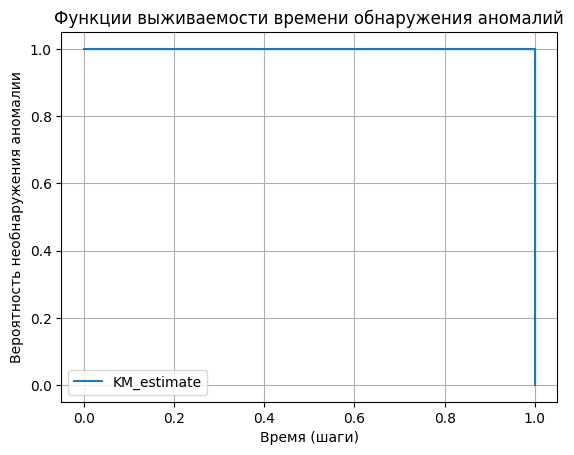

Аномалия 4:
  - Лучший PR AUC: 0.1438 (IsolationForest)
  - Лучший ROC AUC: 0.6926 (LocalOutlierFactor)

-------------------
Время выполнения: 669.4162 секунд


Запуск экспериментов для аномалии 5
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM5.npy


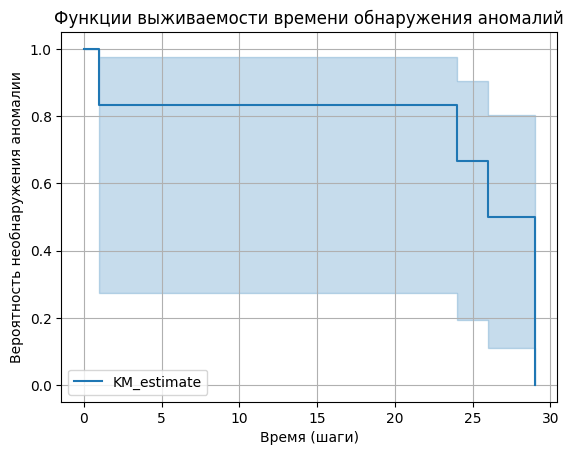

Аномалия 5:
  - Лучший PR AUC: 0.2179 (IsolationForest)
  - Лучший ROC AUC: 0.8326 (IsolationForest)

-------------------
Время выполнения: 675.7088 секунд


Запуск экспериментов для аномалии 6
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM6.npy


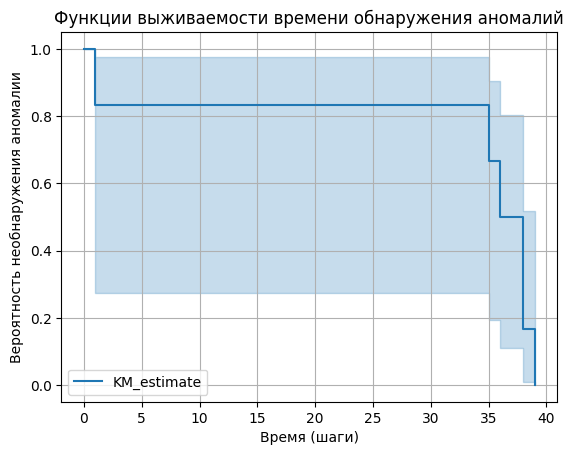

Аномалия 6:
  - Лучший PR AUC: 0.4929 (IsolationForest)
  - Лучший ROC AUC: 0.8899 (IsolationForest)

-------------------
Время выполнения: 698.1097 секунд


Запуск экспериментов для аномалии 7
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM7.npy


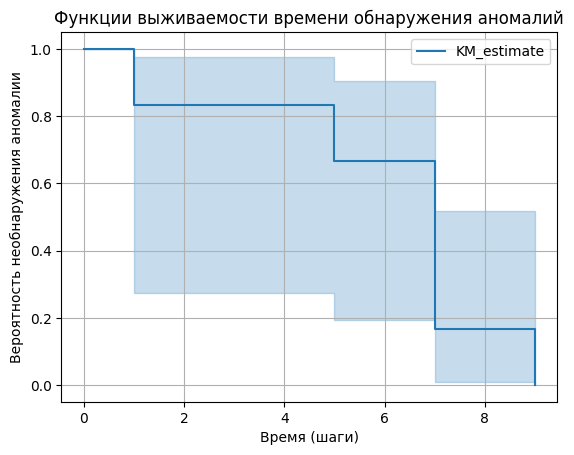

Аномалия 7:
  - Лучший PR AUC: 0.2295 (IsolationForest)
  - Лучший ROC AUC: 0.8436 (IsolationForest)

-------------------
Время выполнения: 675.5199 секунд


Запуск экспериментов для аномалии 8
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM8.npy


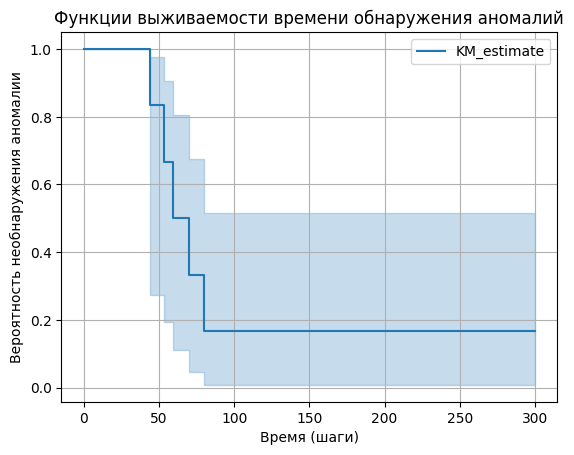

Аномалия 8:
  - Лучший PR AUC: 0.4007 (OneClassSVM)
  - Лучший ROC AUC: 0.8405 (IsolationForest)

-------------------
Время выполнения: 671.6413 секунд


Запуск экспериментов для аномалии 9
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM9.npy


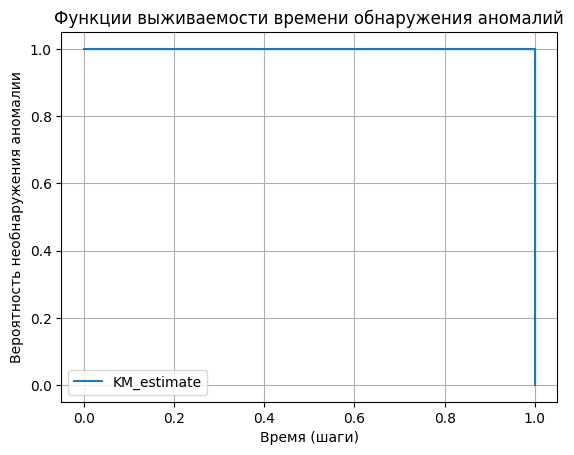

Аномалия 9:
  - Лучший PR AUC: 0.1294 (OneClassSVM)
  - Лучший ROC AUC: 0.5840 (LocalOutlierFactor)

-------------------
Время выполнения: 676.5189 секунд


Запуск экспериментов для аномалии 10
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM10.npy


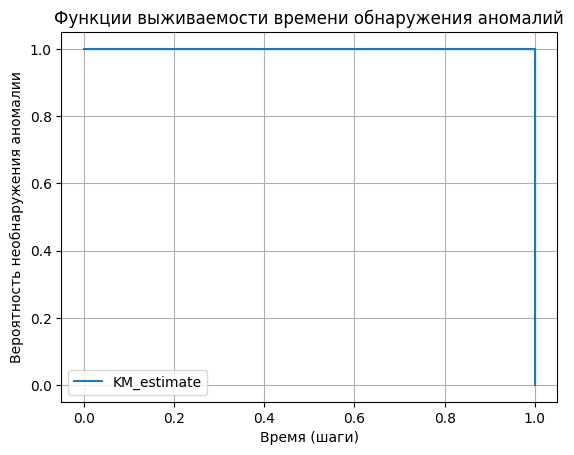

Аномалия 10:
  - Лучший PR AUC: 0.1580 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.7764 (LocalOutlierFactor)

-------------------
Время выполнения: 694.4097 секунд


Запуск экспериментов для аномалии 11
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM11.npy


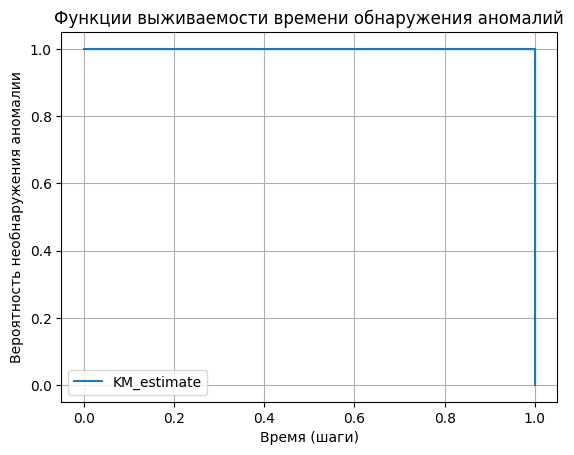

Аномалия 11:
  - Лучший PR AUC: 0.1759 (OneClassSVM)
  - Лучший ROC AUC: 0.7273 (LocalOutlierFactor)

-------------------
Время выполнения: 687.6878 секунд


Запуск экспериментов для аномалии 12
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM12.npy


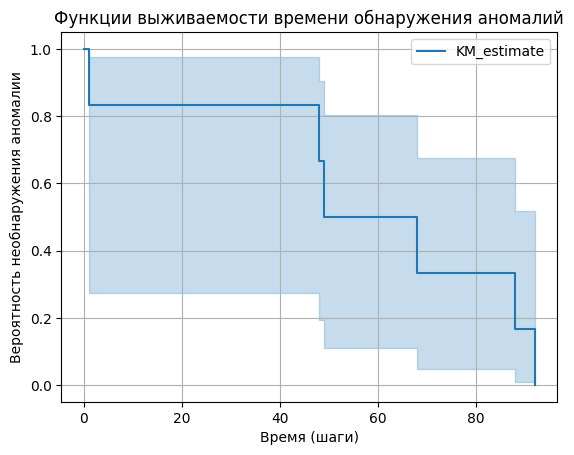

Аномалия 12:
  - Лучший PR AUC: 0.3053 (IsolationForest)
  - Лучший ROC AUC: 0.8440 (IsolationForest)

-------------------
Время выполнения: 674.7717 секунд


Запуск экспериментов для аномалии 13
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM13.npy


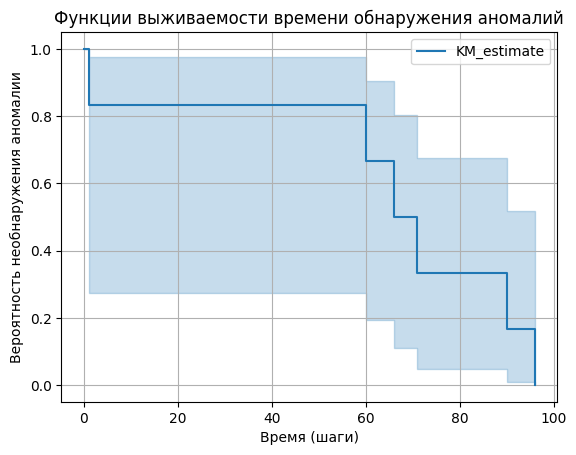

Аномалия 13:
  - Лучший PR AUC: 0.3317 (IsolationForest)
  - Лучший ROC AUC: 0.8148 (IsolationForest)

-------------------
Время выполнения: 696.2217 секунд


Запуск экспериментов для аномалии 14
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM14.npy


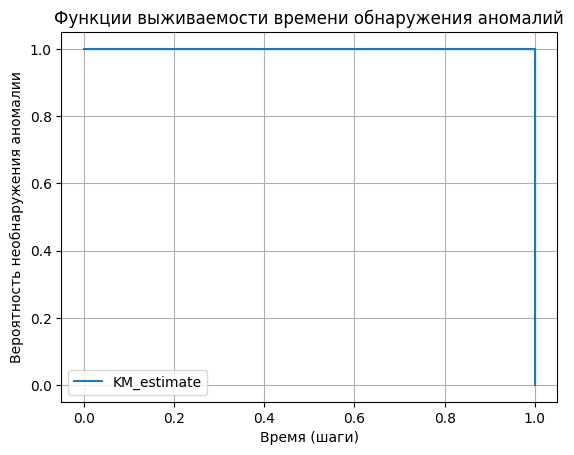

Аномалия 14:
  - Лучший PR AUC: 0.0746 (OneClassSVM)
  - Лучший ROC AUC: 0.5493 (OneClassSVM)

-------------------
Время выполнения: 630.3875 секунд


Запуск экспериментов для аномалии 15
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM15.npy


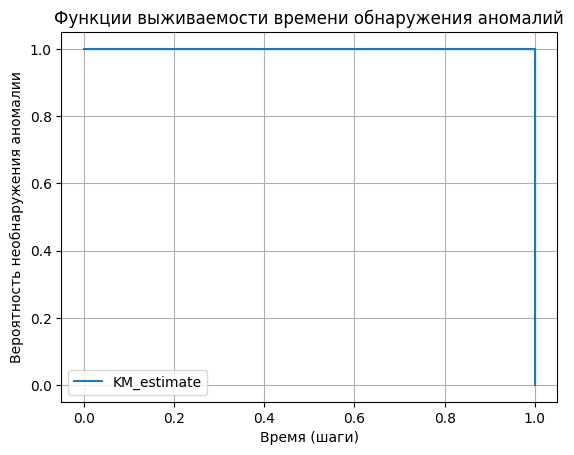

Аномалия 15:
  - Лучший PR AUC: 0.0621 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5751 (LocalOutlierFactor)

-------------------
Время выполнения: 642.4826 секунд


Запуск экспериментов для аномалии 16
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM16.npy


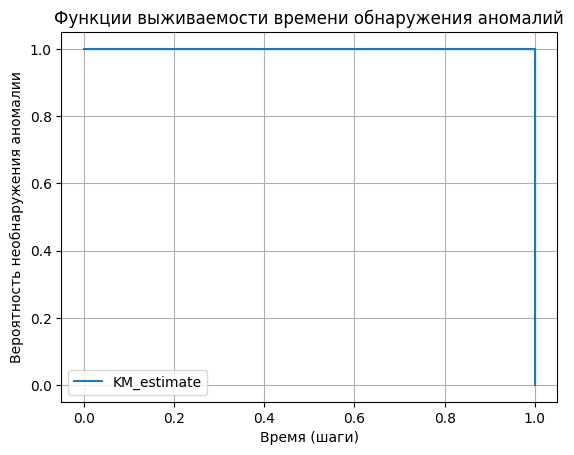

Аномалия 16:
  - Лучший PR AUC: 0.1514 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.7607 (LocalOutlierFactor)

-------------------
Время выполнения: 670.8384 секунд


Запуск экспериментов для аномалии 17
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM17.npy


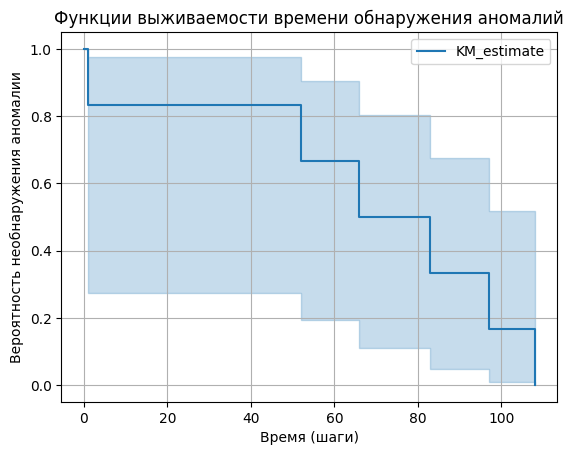

Аномалия 17:
  - Лучший PR AUC: 0.2001 (IsolationForest)
  - Лучший ROC AUC: 0.7822 (IsolationForest)

-------------------
Время выполнения: 667.1434 секунд


Запуск экспериментов для аномалии 18
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(68293, 400), y_train.shape=(68293,), X_test.shape=(31707, 400), y_test.shape=(31707,), y_train.mean()=np.float64(0.05271404097052407), y_test.mean()=np.float64(0.05676979846721544)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM18.npy


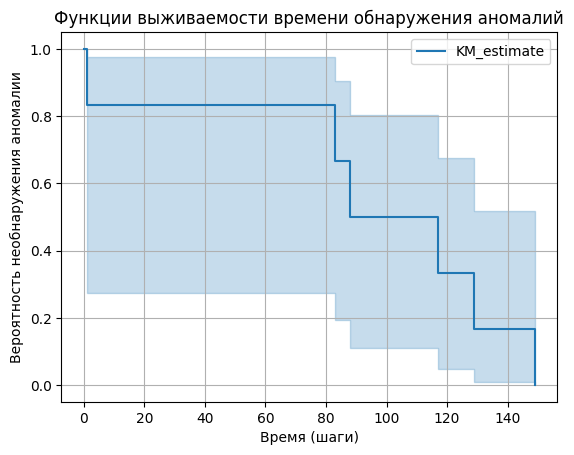

Аномалия 18:
  - Лучший PR AUC: 0.3013 (IsolationForest)
  - Лучший ROC AUC: 0.7749 (IsolationForest)

-------------------
Время выполнения: 677.9839 секунд


Запуск экспериментов для аномалии 19
   Итого: X.shape=(100000, 50, 53), y.shape=(100000,)
   Доля аномалий: 0.0540
Применяем автоэнкодер к данным. Исходная форма: (100000, 50, 53)
После автоэнкодера: (100000, 400)
X_train.shape=(67940, 400), y_train.shape=(67940,), X_test.shape=(32060, 400), y_test.shape=(32060,), y_train.mean()=np.float64(0.05298793052693553), y_test.mean()=np.float64(0.056144728633811605)
Скоры и метки для test сохранены в results/cleared/2026-05-13_08:55:16_rae_w50/scores_ANOM19.npy


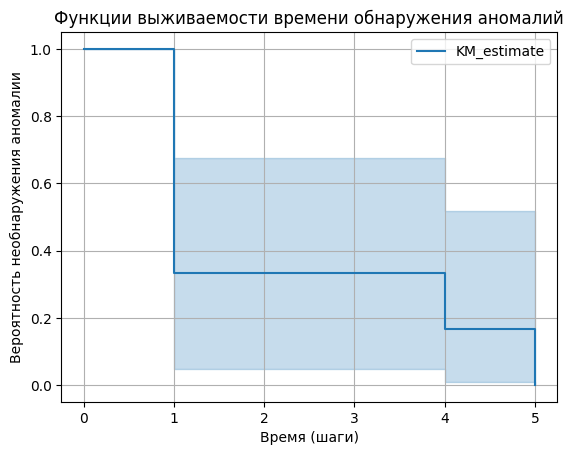

Аномалия 19:
  - Лучший PR AUC: 0.0574 (OneClassSVM)
  - Лучший ROC AUC: 0.5156 (OneClassSVM)

-------------------
Время выполнения: 668.7178 секунд


Сводная таблица сохранена в results/cleared/2026-05-13_08:55:16_rae_w50/best_models_summary.csv
Сводная таблица PR AUC по детекторам сохранена в results/cleared/2026-05-13_08:55:16_rae_w50/pr_auc_pivot.csv


In [7]:
model_params_list = {
    'IsolationForest': [
        # {'n_estimators': 200, 'contamination': 0.1, "random_state": 42},
        {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.1, 'random_state': 42},
        {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.05, 'random_state': 42},
        # {'n_estimators': 50, 'max_samples': 1.0, 'contamination': 0.1, 'random_state': 42},
        # {'n_estimators': 100, 'max_samples': 0.5, 'contamination': 'auto', 'random_state': 42}
    ],
    'LocalOutlierFactor': [
        # {'n_neighbors': 50, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 20, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 10, 'contamination': 0.05, 'novelty': True},
        # {'n_neighbors': 10, 'contamination': 0.1, 'novelty': True},
        # {'n_neighbors': 50, 'contamination': 0.15, 'novelty': True},
        {'n_neighbors': 20, 'contamination': 'auto', 'novelty': True}
    ],
    'OneClassSVM': [
        # {'kernel': 'rbf', 'nu': 0.1},
        # {'kernel': 'rbf', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.15},
        # {'kernel': 'linear', 'nu': 0.2},
        # {'kernel': 'linear', 'nu': 0.10},
        # {'kernel': 'poly', 'nu': 0.15},
    ],
    # 'GradientBoosting': [
    #     {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42},
    #     {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42},
    #     {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'random_state': 42},
    # ]
}

anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]
window = 50

autoencoder = RecurrentAutoencoder.from_pretrained(f"./models/new_autoencoder_w{window}_v3.pth")
autoencoder.eval()

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_large_warmup/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.2,
                                     anomaly_ratio=0.10,
                                     window=window,
                                     result_title=f"rae_w{window}",
                                     results_path="results/cleared",
                                     autoencoder=autoencoder
                                     )

In [8]:
summary_detectors

detector,IsolationForest,LocalOutlierFactor,OneClassSVM
anomaly_number,,,
1,0.267384,0.173788,0.036475
2,0.277238,0.206282,0.288570
3,0.106169,0.103395,0.050027
4,0.143809,0.129211,0.037370
5,0.217924,0.098981,0.175139
6,0.492934,0.220355,0.074013
7,0.229549,0.112908,0.139450
8,0.324000,0.129627,0.400670
9,0.099575,0.117283,0.129392


In [ ]:
# not reduced, autoencoder
anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_new/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.05,
                                     anomaly_ratio=0.08,
                                     window=None,
                                     result_title="new_data_unsupervisedwith_autoencoder",
                                     results_path="results/cleared",
                                     autoencoder=autoencoder
                                     )

In [ ]:
summary_detectors